# Modeling Assignment - SWIRE

By: Ali Ladha

# Importing Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import csv

def load_google_analytics_csv(path: str) -> pd.DataFrame:
    # Attempt 1: strict but tolerant engine + normal quoting/escaping
    try:
        return pd.read_csv(
            path,
            sep=",",
            engine="python",
            quotechar='"',
            escapechar="\\",
            doublequote=False,     # respect backslash escaping
            on_bad_lines="warn",   # don't crash; tell us which lines were bad
        )
    except Exception as e1:
        print("Attempt 1 failed:", e1)

    # Attempt 2: disable CSV quoting entirely (treat quotes as normal chars).
    # Requires an escapechar; good for files with inconsistent quotes.
    try:
        return pd.read_csv(
            path,
            sep=",",
            engine="python",
            quoting=csv.QUOTE_NONE,
            escapechar="\\",
            on_bad_lines="warn",
        )
    except Exception as e2:
        print("Attempt 2 failed:", e2)

    # Attempt 3: let pandas sniff the delimiter; still python engine and forgiving
    try:
        return pd.read_csv(
            path,
            sep=None,              # auto-detect delimiter
            engine="python",
            on_bad_lines="warn",
        )
    except Exception as e3:
        print("Attempt 3 failed:", e3)
        raise

google_analytics = load_google_analytics_csv("clean_GA 1.csv")


In [4]:
customer         = pd.read_csv('clean_customer.csv')
cutoff_times     = pd.read_csv('clean_cutoff_times.csv')  # <- renamed var
materials        = pd.read_csv('clean_material.csv')
operating_hours  = pd.read_csv('clean_operating_hours.csv')
orders           = pd.read_csv('clean_orders.csv')
sales            = pd.read_csv('clean_sales.csv')
visit_plan       = pd.read_csv('clean_visit_plan.csv')

for df in [customer, cutoff_times, google_analytics, materials,
           operating_hours, orders, sales, visit_plan]:
    df.columns = df.columns.str.lower()


In [5]:
# Reading in main df with the abandoned label:
df = pd.read_csv('clean_GA 1.csv')


In [6]:
df.head()


,customer_id,event_name,device_category,device_mobile_brand_name,device_operating_system,event_page_name,event_page_title,items,event_date,event_ts_utc,abandoned,purchase_segment,False_by_purchase,recovered
0,500245685,page_view,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2024-06-13,2024-06-13 04:43:59.908000+00:00,False,500245685.5,no purchase,not applicable
1,500245685,page_view,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2024-06-13,2024-06-13 04:43:59.908000+00:00,False,500245685.5,no purchase,not applicable
2,500245685,nav_link_click,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2024-06-13,2024-06-13 04:44:27.635000+00:00,False,500245685.5,no purchase,not applicable
3,500245685,page_view,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2024-06-13,2024-06-13 04:44:27.635000+00:00,False,500245685.5,no purchase,not applicable
4,500245685,page_view,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2024-06-13,2024-06-13 04:44:27.635000+00:00,False,500245685.5,no purchase,not applicable


In [7]:
df.shape

(3704088, 14)

In [8]:
# Removing inactive records (mask)
df[ (df['abandoned'] == False) & (df['False_by_purchase'] == 'no purchase') & (df['recovered'] == 'not applicable')].shape # inactive records
# filtering out inactive records
df = df[~( (df['abandoned'] == False) & (df['False_by_purchase'] == 'no purchase') & (df['recovered'] == 'not applicable'))]



# Modelling - Ali

In [9]:
display(df.head())
display(df.shape)
display(df.info())


,customer_id,event_name,device_category,device_mobile_brand_name,device_operating_system,event_page_name,event_page_title,items,event_date,event_ts_utc,abandoned,purchase_segment,False_by_purchase,recovered
340,500245685,page_view,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2025-02-20,2025-02-20 20:02:24.422000+00:00,False,5.002457e+08,purchased,not applicable
341,500245685,page_view,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2025-02-20,2025-02-20 20:02:30.456000+00:00,False,5.002457e+08,purchased,not applicable
342,500245685,page_view,Desktop,Google,Windows,Mycoke Dashboard,Home,[],2025-02-20,2025-02-20 20:02:30.456000+00:00,False,5.002457e+08,purchased,not applicable
343,500245685,page_view,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2025-02-20,2025-02-20 20:02:38.168000+00:00,False,5.002457e+08,purchased,not applicable
344,500245685,page_view,Desktop,Google,Windows,Mycoke Invoices,Invoice-list,[],2025-02-20,2025-02-20 20:02:38.168000+00:00,False,5.002457e+08,purchased,not applicable


(3133610, 14)

<class 'pandas.core.frame.DataFrame'>
Index: 3133610 entries, 340 to 3703924
Data columns (total 14 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   customer_id               int64  
 1   event_name                object 
 2   device_category           object 
 3   device_mobile_brand_name  object 
 4   device_operating_system   object 
 5   event_page_name           object 
 6   event_page_title          object 
 7   items                     object 
 8   event_date                object 
 9   event_ts_utc              object 
 10  abandoned                 object 
 11  purchase_segment          float64
 12  False_by_purchase         object 
 13  recovered                 object 
dtypes: float64(1), int64(1), object(12)
memory usage: 358.6+ MB


None

In [10]:
# Need to expand this json dict

display(df['items'].unique())

import pandas as pd
import numpy as np
import json, ast

# 1) Parse the 'items' column directly into lists of dicts
df["items"] = (
    df["items"]
    .fillna("[]")
    .astype(str)
    .str.strip()
    .apply(
        lambda s: [] if s in ("", "[]")
        else (
            json.loads(s) if '"' in s else ast.literal_eval(s)
        )
    )
)

# 2) Explode so each item gets its own row
df = df.explode("items", ignore_index=True)

# 3) Extract item_id and quantity from each dict
df["item_id"] = df["items"].map(
    lambda d: d.get("item_id") if isinstance(d, dict) else None
)
df["quantity"] = df["items"].map(
    lambda d: d.get("quantity") if isinstance(d, dict) else None
)

# 4) Clean up column types
df["item_id"] = df["item_id"].astype("string")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce").astype("Int64")

# 5) Remove rows with no items
df = df[df["item_id"].notna()].reset_index(drop=True)

# Done — df is now in tidy, exploded format
print(df.head())


array(['[]', "[{'item_id': '104631', 'quantity': '1'}]",
       "[{'item_id': '104631', 'quantity': '0'}]", ...,
       "[{'item_id': '156345', 'quantity': '1'}, {'item_id': '155361', 'quantity': '1'}, {'item_id': '155207', 'quantity': '1'}, {'item_id': '155184', 'quantity': '1'}, {'item_id': '157135', 'quantity': '1'}, {'item_id': '155186', 'quantity': '1'}, {'item_id': '151778', 'quantity': '1'}, {'item_id': '156136', 'quantity': '1'}, {'item_id': '156085', 'quantity': '1'}, {'item_id': '156845', 'quantity': '1'}, {'item_id': '156571', 'quantity': '1'}, {'item_id': '156340', 'quantity': '1'}, {'item_id': '156843', 'quantity': '1'}, {'item_id': '155206', 'quantity': '1'}, {'item_id': '156184', 'quantity': '1'}, {'item_id': '155811', 'quantity': '1'}, {'item_id': '156112', 'quantity': '1'}, {'item_id': '156118', 'quantity': '1'}, {'item_id': '152944', 'quantity': '1'}, {'item_id': '155016', 'quantity': '1'}, {'item_id': '156137', 'quantity': '1'}, {'item_id': '156110', 'quantity': '1'}

   customer_id        event_name device_category device_mobile_brand_name  \
0    500245685    view_item_list         Desktop                   Google   
1    500245685    view_item_list         Desktop                   Google   
2    500245685       add_to_cart         Desktop                   Google   
3    500245685  remove_from_cart         Desktop                   Google   
4    500245685  remove_from_cart         Desktop                   Google   

  device_operating_system       event_page_name event_page_title  \
0                 Windows          Unknown Page           Search   
1                 Windows          Unknown Page    Category: Co2   
2                 Windows          Unknown Page    Category: Co2   
3                 Windows  Mycoke Orders - Cart             Cart   
4                 Windows  Mycoke Orders - Cart             Cart   

                                    items  event_date  \
0  {'item_id': '104631', 'quantity': '1'}  2025-02-20   
1  {'item_id':

In [11]:
# Removing previous items column as they've now been expanded
df = df.drop(columns=['items'])

In [12]:
df['item_id'].unique()

# Dropping records that have str item_ids:  '01t7V00000A14YXQAZ', '01t7V000007myALQAY', '01t1U000005ZjcMQAS',
#  '01t1U000005ZksMQAS', '01t7V000007mxJKQAY', '01t1U000005ZjTKQA0',
#  '01t1U000005ZjTbQAK', '01t1U000005ZkYSQA0', '01t1U000005Zj33QAC',
#  '01t1U000005ZjbpQAC']

df = df[~df['item_id'].str.startswith('01t')].reset_index(drop=True)
df['item_id'] = df['item_id'].astype(int)

In [13]:
# downsampling model:
df['abandoned'].value_counts(normalize=True)

print(f'The majority class is abandoned = False is around 90% so we should downsample the True class to a 2:1 Ratio.')


The majority class is abandoned = False is around 90% so we should downsample the True class to a 2:1 Ratio.


In [14]:
display(df.isnull().sum()) # There are 5463 null records. Dropping the nulls for modelling.
df = df.dropna().reset_index(drop=True)

customer_id                    0
event_name                     0
device_category                0
device_mobile_brand_name       0
device_operating_system        0
event_page_name                0
event_page_title               0
event_date                     0
event_ts_utc                   0
abandoned                   3841
purchase_segment            3841
False_by_purchase           3841
recovered                   3841
item_id                        0
quantity                       0
dtype: int64

In [15]:
df.isnull().sum()

customer_id                 0
event_name                  0
device_category             0
device_mobile_brand_name    0
device_operating_system     0
event_page_name             0
event_page_title            0
event_date                  0
event_ts_utc                0
abandoned                   0
purchase_segment            0
False_by_purchase           0
recovered                   0
item_id                     0
quantity                    0
dtype: int64

In [16]:
df.isnull().sum()

customer_id                 0
event_name                  0
device_category             0
device_mobile_brand_name    0
device_operating_system     0
event_page_name             0
event_page_title            0
event_date                  0
event_ts_utc                0
abandoned                   0
purchase_segment            0
False_by_purchase           0
recovered                   0
item_id                     0
quantity                    0
dtype: int64

In [17]:
df = df.dropna()

In [18]:
df.head()

,customer_id,event_name,device_category,device_mobile_brand_name,device_operating_system,event_page_name,event_page_title,event_date,event_ts_utc,abandoned,purchase_segment,False_by_purchase,recovered,item_id,quantity
0,500245685,view_item_list,Desktop,Google,Windows,Unknown Page,Search,2025-02-20,2025-02-20 20:05:09.962000+00:00,False,5.002457e+08,purchased,not applicable,104631,1
1,500245685,view_item_list,Desktop,Google,Windows,Unknown Page,Category: Co2,2025-02-20,2025-02-20 20:05:28.122000+00:00,False,5.002457e+08,purchased,not applicable,104631,1
2,500245685,add_to_cart,Desktop,Google,Windows,Unknown Page,Category: Co2,2025-02-20,2025-02-20 20:08:17.399000+00:00,False,5.002457e+08,purchased,not applicable,104631,1
3,500245685,remove_from_cart,Desktop,Google,Windows,Mycoke Orders - Cart,Cart,2025-02-20,2025-02-20 20:09:26.094000+00:00,False,5.002457e+08,purchased,not applicable,104631,0
4,500245685,remove_from_cart,Desktop,Google,Windows,Mycoke Orders - Cart,Cart,2025-02-20,2025-02-20 20:09:45.050000+00:00,False,5.002457e+08,purchased,not applicable,104631,0


In [19]:
# Finding the majority class
display(df['abandoned'].value_counts())
display(df['abandoned'].value_counts(normalize=True))

abandoned
False    4474747
True      694479
Name: count, dtype: int64

abandoned
False    0.865651
True     0.134349
Name: proportion, dtype: float64

# Modelling - Ali

In [21]:
# ===========================
# 0) SETUP & SHARED PREP CELL
# ===========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

# --- 0.1: basic feature engineering ---
df_prep = df.copy()

# parse times
df_prep["event_date"]   = pd.to_datetime(df_prep["event_date"], errors="coerce")
df_prep["event_ts_utc"] = pd.to_datetime(df_prep["event_ts_utc"], errors="coerce")

# simple time features
df_prep["dow"]  = df_prep["event_date"].dt.dayofweek
df_prep["hour"] = df_prep["event_ts_utc"].dt.hour

# drop NaNs *after* creating features so dow/hour are clean
df_prep = df_prep.dropna().reset_index(drop=True)
print("After dropna:", df_prep.shape)

# target + features
y = df_prep["abandoned"].astype(int)
feature_cols = [
    "event_name",
    "device_category",
    "device_mobile_brand_name",
    "device_operating_system",
    "event_page_name",
    "quantity", "dow", "hour"
]
X = df_prep[feature_cols]

# --- 0.2: split BEFORE downsampling (keep test honest) ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# --- 0.3: downsample majority to 2:1 on TRAIN only ---
counts = y_train_full.value_counts()
maj_label = counts.idxmax()
min_label = counts.idxmin()
n_min = counts[min_label]
n_maj_target = 2 * n_min

maj_idx = y_train_full[y_train_full == maj_label].index
min_idx = y_train_full[y_train_full == min_label].index

rng = np.random.RandomState(42)
maj_idx_down = rng.choice(maj_idx, size=min(n_maj_target, len(maj_idx)), replace=False)
down_idx = np.concatenate([min_idx, maj_idx_down])

X_train = X_train_full.loc[down_idx].reset_index(drop=True)
y_train = y_train_full.loc[down_idx].reset_index(drop=True)

print("Train class balance BEFORE:", counts.to_dict())
print("Train class balance AFTER: ", y_train.value_counts().to_dict())

# --- 0.4: preprocessing (scale numerics + OHE categoricals) ---
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# --- 0.5: make a smaller CV subset for speed; we refit best on full train later ---
cv_frac = 0.6  # use 60% of downsampled train for CV
X_train_cv, _, y_train_cv, _ = train_test_split(
    X_train, y_train, train_size=cv_frac, stratify=y_train, random_state=42
)
print(f"Using {cv_frac*100:.0f}% of downsampled train for CV:", X_train_cv.shape)

# --- 0.6: helper to evaluate on TEST (prints outputs) ---
def evaluate_on_test(name, fitted_model):
    print(f"\n##### {name} — Test Performance #####")
    y_pred = fitted_model.predict(X_test)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))
    if hasattr(fitted_model, "predict_proba"):
        y_prob = fitted_model.predict_proba(X_test)[:, 1]
        ap = average_precision_score(y_test, y_prob)
        print(f"Average Precision (PR-AUC): {ap:.4f}")


After dropna: (5163989, 17)
Train class balance BEFORE: {0: 3576172, 1: 555019}
Train class balance AFTER:  {0: 1110038, 1: 555019}
Using 60% of downsampled train for CV: (999034, 8)


In [22]:
# ===========================
# 1) RANDOM FOREST (fast CV)
# ===========================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    max_samples=0.7,   # speed: each tree uses 70% of rows
    bootstrap=True
)
rf_pipe = Pipeline([("prep", preprocessor), ("model", rf)])

rf_params = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [8, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params,
    n_iter=3, cv=2, scoring="f1",
    n_jobs=-1, random_state=42, verbose=2
)

print("\n=== RF: quick CV on subset ===")
rf_search.fit(X_train_cv, y_train_cv)
print("RF best params (subset):", rf_search.best_params_)

# refit best on FULL downsampled train
rf_best = rf_search.best_estimator_
rf_best.fit(X_train, y_train)

# show outputs on TEST
evaluate_on_test("Random Forest", rf_best)



=== RF: quick CV on subset ===
Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END model__max_depth=8, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=250; total time=  50.4s
[CV] END model__max_depth=8, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=250; total time=  52.8s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=150; total time= 3.0min
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=150; total time= 3.1min
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=250; total time= 3.3min
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimato

In [23]:
# ==================================
# 2) LOGISTIC REGRESSION (fast CV)
# ==================================
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  # helps minority class
    solver="saga",
    n_jobs=-1
)
log_pipe = Pipeline([("prep", preprocessor), ("model", log_reg)])

log_params = {
    "model__C": [0.1, 1.0, 3.0],
    "model__penalty": ["l1", "l2"]
}

log_search = RandomizedSearchCV(
    log_pipe, log_params,
    n_iter=3, cv=2, scoring="f1",
    n_jobs=-1, random_state=42, verbose=2
)

print("\n=== LogReg: quick CV on subset ===")
log_search.fit(X_train_cv, y_train_cv)
print("LogReg best params (subset):", log_search.best_params_)

# refit best on FULL downsampled train
log_best = log_search.best_estimator_
log_best.fit(X_train, y_train)

# show outputs on TEST
evaluate_on_test("Logistic Regression", log_best)



=== LogReg: quick CV on subset ===
Fitting 2 folds for each of 3 candidates, totalling 6 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ....................model__C=3.0, model__penalty=l2; total time= 8.6min
[CV] END ....................model__C=0.1, model__penalty=l2; total time= 8.6min
[CV] END ....................model__C=0.1, model__penalty=l2; total time= 8.6min


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ....................model__C=3.0, model__penalty=l2; total time= 8.6min


...

[CV] END ....................model__C=0.1, model__penalty=l1; total time=10.0min


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg best params (subset): {'model__penalty': 'l1', 'model__C': 0.1}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



##### Logistic Regression — Test Performance #####
Confusion Matrix:
 [[434702 459341]
 [ 41942  96813]]
              precision    recall  f1-score   support

           0      0.912     0.486     0.634    894043
           1      0.174     0.698     0.279    138755

    accuracy                          0.515   1032798
   macro avg      0.543     0.592     0.456   1032798
weighted avg      0.813     0.515     0.587   1032798

Average Precision (PR-AUC): 0.1990


In [24]:
# ======================
# 3) XGBOOST (fast CV)
# ======================
try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError("Please run: pip install xgboost") from e

xgb = XGBClassifier(
    random_state=42,
    tree_method="hist",     # fast histogram algorithm
    eval_metric="logloss",
    n_jobs=-1
)
xgb_pipe = Pipeline([("prep", preprocessor), ("model", xgb)])

xgb_params = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params,
    n_iter=3, cv=2, scoring="f1",
    n_jobs=-1, random_state=42, verbose=2
)

print("\n=== XGB: quick CV on subset ===")
xgb_search.fit(X_train_cv, y_train_cv)
print("XGB best params (subset):", xgb_search.best_params_)

# refit best on FULL downsampled train
xgb_best = xgb_search.best_estimator_
xgb_best.fit(X_train, y_train)

# show outputs on TEST
evaluate_on_test("XGBoost", xgb_best)



=== XGB: quick CV on subset ===
Fitting 2 folds for each of 3 candidates, totalling 6 fits
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=4, model__n_estimators=150, model__subsample=0.8; total time=   4.9s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=4, model__n_estimators=150, model__subsample=0.8; total time=   5.0s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=150, model__subsample=1.0; total time=   6.1s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=150, model__subsample=1.0; total time=   6.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=250, model__subsample=1.0; total time=   8.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=250, model__subsample=1.0; total time=   8.3s
XGB best

## Tuning XGBoost further

In [25]:
# ============================================
# XGBoost: push class-1 F1 (tuned threshold)
# ============================================
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix
)

# 1) Minimal feature build + drop NaNs (so modeling is deterministic)
df_x = df.copy()
df_x["event_date"]   = pd.to_datetime(df_x["event_date"], errors="coerce")
df_x["event_ts_utc"] = pd.to_datetime(df_x["event_ts_utc"], errors="coerce")
df_x["dow"]  = df_x["event_date"].dt.dayofweek
df_x["hour"] = df_x["event_ts_utc"].dt.hour
df_x = df_x.dropna().reset_index(drop=True)

y = df_x["abandoned"].astype(int)
feat_cols = [
    "event_name",
    "device_category",
    "device_mobile_brand_name",
    "device_operating_system",
    "event_page_name",
    "quantity", "dow", "hour"
]
X = df_x[feat_cols]

# 2) Hold-out TEST first (keep honest)
X_tr_all, X_test, y_tr_all, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 3) From TRAIN, carve out a VALIDATION split (for early stopping & threshold tuning)
X_tr_raw, X_val_raw, y_tr_raw, y_val_raw = train_test_split(
    X_tr_all, y_tr_all, test_size=0.10, stratify=y_tr_all, random_state=42
)

# 4) Two downsampling strategies – 2:1 and 1:1 (majority:minority)
def downsample(Xin, yin, ratio=2):
    vc = yin.value_counts()
    maj = vc.idxmax(); mino = vc.idxmin()
    n_min = vc[mino]
    n_maj_tgt = ratio * n_min
    rng = np.random.RandomState(42)
    maj_idx = yin[yin == maj].index
    keep_maj = rng.choice(maj_idx, size=min(n_maj_tgt, len(maj_idx)), replace=False)
    keep_idx = np.concatenate([yin[yin == mino].index, keep_maj])
    return Xin.loc[keep_idx].reset_index(drop=True), yin.loc[keep_idx].reset_index(drop=True)

train_variants = {
    "ds_2to1": downsample(X_tr_raw, y_tr_raw, ratio=2),
    "ds_1to1": downsample(X_tr_raw, y_tr_raw, ratio=1),
}

# 5) Preprocessor: scale numerics + OHE categoricals
def build_preprocessor(Xtrain):
    num_cols = Xtrain.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = Xtrain.select_dtypes(include=["object","category"]).columns.tolist()
    pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    return pre, num_cols, cat_cols

# helper to predict using the best iteration
def pred_proba_best(bst, dmat):
    if hasattr(bst, "best_iteration") and bst.best_iteration is not None:
        try:
            return bst.predict(dmat, iteration_range=(0, bst.best_iteration + 1))
        except TypeError:
            pass
    if hasattr(bst, "best_ntree_limit") and bst.best_ntree_limit is not None:
        return bst.predict(dmat, ntree_limit=bst.best_ntree_limit)
    return bst.predict(dmat)

# 6) Tiny hyperparam sweep (fast), early stop on VAL, choose threshold by max F1(positive)
configs = []
param_grid = [
    # Lower LR + deeper trees (with early stopping)
    {"eta":0.05, "max_depth":6, "subsample":0.8, "colsample_bytree":0.8, "spw":1.0},
    {"eta":0.05, "max_depth":8, "subsample":0.8, "colsample_bytree":0.8, "spw":1.2},
    # Slightly higher LR + medium depth
    {"eta":0.10, "max_depth":6, "subsample":0.8, "colsample_bytree":0.8, "spw":1.0},
    {"eta":0.10, "max_depth":6, "subsample":1.0, "colsample_bytree":1.0, "spw":1.5},
    # Regularization tweaks
    {"eta":0.05, "max_depth":6, "subsample":0.9, "colsample_bytree":0.9, "spw":1.5},
    {"eta":0.10, "max_depth":4, "subsample":1.0, "colsample_bytree":1.0, "spw":2.0},
]

for tag, (Xtr, ytr) in train_variants.items():
    pre, num_cols, cat_cols = build_preprocessor(Xtr)
    Xtr_p  = pre.fit_transform(Xtr)
    Xval_p = pre.transform(X_val_raw)
    Xtest_p= pre.transform(X_test)

    # scale_pos_weight based on the *downsampled* train counts, then multiplied by grid spw
    neg = int((ytr == 0).sum()); pos = int((ytr == 1).sum())
    base_spw = max(1.0, neg / max(1, pos))

    dtr   = xgb.DMatrix(Xtr_p,  label=ytr)
    dval  = xgb.DMatrix(Xval_p, label=y_val_raw)
    dtest = xgb.DMatrix(Xtest_p)

    for p in param_grid:
        params = {
            "objective": "binary:logistic",
            "eval_metric": ["logloss", "aucpr"],  # PR-AUC is useful for imbalance
            "tree_method": "hist",
            "eta": p["eta"],
            "max_depth": p["max_depth"],
            "subsample": p["subsample"],
            "colsample_bytree": p["colsample_bytree"],
            "scale_pos_weight": base_spw * p["spw"],  # let search test a bit stronger weighting
            "lambda": 1.0,   # L2
            "alpha": 0.0,    # L1 (tune later if needed)
            "verbosity": 0
        }

        bst = xgb.train(
            params=params,
            dtrain=dtr,
            num_boost_round=800,             # early stopping will cap it
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        # Choose threshold on VAL to maximize F1 for class=1
        yv = pred_proba_best(bst, dval)
        prec, rec, thr = precision_recall_curve(y_val_raw, yv)
        f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
        best_idx = int(np.nanargmax(f1))
        thr_star = thr[min(best_idx, len(thr)-1)] if len(thr) > 0 else 0.5
        val_f1 = float(f1[best_idx])
        val_ap = float(average_precision_score(y_val_raw, yv))

        configs.append({
            "variant": tag,
            "params": p,
            "best_iter": getattr(bst, "best_iteration", None),
            "val_f1": val_f1,
            "val_ap": val_ap,
            "thr": float(thr_star),
            "bst": bst,
            "pre": pre
        })

# 7) Leaderboard by VAL F1 (what we optimized for)
configs = sorted(configs, key=lambda z: z["val_f1"], reverse=True)
print("\n=== XGB Leaderboard (by Validation F1 for class=1) ===")
for r in configs[:5]:
    print(f"{r['variant']} | F1={r['val_f1']:.3f} | PR-AUC={r['val_ap']:.3f} | thr={r['thr']:.3f} "
          f"| iter={r['best_iter']} | params={r['params']}")

# 8) Evaluate the best config on TEST at its tuned threshold
best = configs[0]
pre = best["pre"]
Xtest_p = pre.transform(X_test)
dtest   = xgb.DMatrix(Xtest_p)

y_test_prob = pred_proba_best(best["bst"], dtest)
y_test_pred = (y_test_prob >= best["thr"]).astype(int)

print("\n=== TEST @ tuned threshold (picked on VAL F1) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, digits=3))
print(f"Test PR-AUC: {average_precision_score(y_test, y_test_prob):.4f}")
print("\nBest config used:")
print(best["variant"], best["params"], "best_iter:", best["best_iter"], "thr:", round(best["thr"], 3))



=== XGB Leaderboard (by Validation F1 for class=1) ===
ds_2to1 | F1=0.324 | PR-AUC=0.293 | thr=0.611 | iter=799 | params={'eta': 0.05, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.8, 'spw': 1.2}
ds_2to1 | F1=0.323 | PR-AUC=0.291 | thr=0.541 | iter=799 | params={'eta': 0.1, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'spw': 1.0}
ds_1to1 | F1=0.323 | PR-AUC=0.292 | thr=0.605 | iter=799 | params={'eta': 0.05, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.8, 'spw': 1.2}
ds_1to1 | F1=0.323 | PR-AUC=0.290 | thr=0.542 | iter=795 | params={'eta': 0.1, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'spw': 1.0}
ds_2to1 | F1=0.322 | PR-AUC=0.288 | thr=0.639 | iter=791 | params={'eta': 0.1, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 1.0, 'spw': 1.5}

=== TEST @ tuned threshold (picked on VAL F1) ===
Confusion Matrix:
 [[689761 204282]
 [ 72523  66232]]
              precision    recall  f1-score   support

           0      0.905     0.77

# Independant Questions

1. How does cart abandonment vary by device type and how can it be reduced?
2. Which products appear most frequently in abandoned carts?


## Question 1. How does cart abandonment vary by device type and how can it be reduced?

  device_category abandonment_rate
2          Tablet         0.218084
1          Mobile         0.207434
0         Desktop         0.127895


/var/folders/g1/_r53jbfn2tg_0kcxz7b3cwg40000gn/T/ipykernel_94839/4157597178.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="device_category", y="abandonment_rate", data=device_abandon, palette="crest")


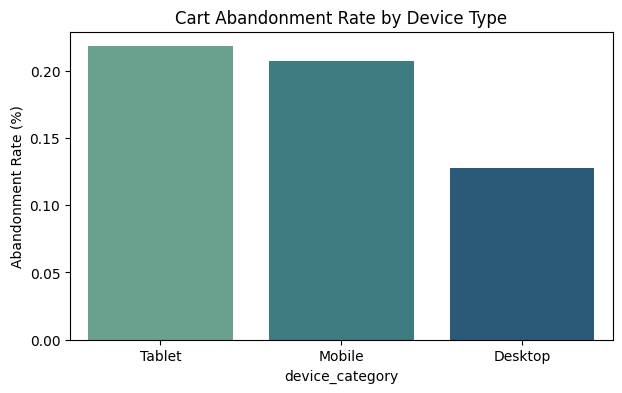

In [26]:
# --- Cart abandonment rate by device type ---
device_abandon = (
    df.groupby("device_category")["abandoned"]
    .mean()
    .reset_index()
    .rename(columns={"abandoned": "abandonment_rate"})
    .sort_values("abandonment_rate", ascending=False)
)

print(device_abandon)

# Optional: visualize
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.barplot(x="device_category", y="abandonment_rate", data=device_abandon, palette="crest")
plt.title("Cart Abandonment Rate by Device Type")
plt.ylabel("Abandonment Rate (%)")
plt.show()


Out of all device types, Tablets have the highest abandoned rates followed by mobile, then desktops. With an abandoned rate of 21.8% for tablets, this could be due to UI difficulties. This is significant as tablets themselves are the rarest device used when navigating through MyCoke360, yet represent the highest abandon rate. Mobile is close to the abandonment rate as Tablet at 20.7%. This could indiciate difficulties due to ordering with a smaller screen size. Revising the MyCoke360 webpage to ease Tablet and Mobile orders could be worth implementing and the results can be later compared via an A/B test.

## Question 2.# Analyzing which products appear most frequently in abandoned carts

In [27]:
df.head()

,customer_id,event_name,device_category,device_mobile_brand_name,device_operating_system,event_page_name,event_page_title,event_date,event_ts_utc,abandoned,purchase_segment,False_by_purchase,recovered,item_id,quantity
0,500245685,view_item_list,Desktop,Google,Windows,Unknown Page,Search,2025-02-20,2025-02-20 20:05:09.962000+00:00,False,5.002457e+08,purchased,not applicable,104631,1
1,500245685,view_item_list,Desktop,Google,Windows,Unknown Page,Category: Co2,2025-02-20,2025-02-20 20:05:28.122000+00:00,False,5.002457e+08,purchased,not applicable,104631,1
2,500245685,add_to_cart,Desktop,Google,Windows,Unknown Page,Category: Co2,2025-02-20,2025-02-20 20:08:17.399000+00:00,False,5.002457e+08,purchased,not applicable,104631,1
3,500245685,remove_from_cart,Desktop,Google,Windows,Mycoke Orders - Cart,Cart,2025-02-20,2025-02-20 20:09:26.094000+00:00,False,5.002457e+08,purchased,not applicable,104631,0
4,500245685,remove_from_cart,Desktop,Google,Windows,Mycoke Orders - Cart,Cart,2025-02-20,2025-02-20 20:09:45.050000+00:00,False,5.002457e+08,purchased,not applicable,104631,0


In [28]:
materials.head()

,material_id,trademark,flavor,beverage_category,packaging_type,packaging_size
0,125522,Oliver Originals,Salted Caramel,CORE SPARKLING,Plastic Bottle - Other,20 oz
1,116974,Sunny Sip,Passionfruit,Other,Styrofoam Lid,24 oz
2,113144,Sam's,Bubblegum,JUICES/NECTARS,Bag-In-Box,2.5 gal
3,410256,Jack's Juices,Cappuccino,CORE SPARKLING,Aluminum Can,12 oz
4,146980,Oliver Originals,Vanilla Latte,CORE SPARKLING,Aluminum Can,16 oz


In [29]:
# Show unique combinations of material_id ↔ trademark
unique_combos = materials[["material_id", "trademark"]].drop_duplicates()

print(unique_combos.shape)
print(unique_combos.head(20))  # show first 20 rows



(1252, 2)
    material_id         trademark
0        125522  Oliver Originals
1        116974         Sunny Sip
2        113144             Sam's
3        410256     Jack's Juices
4        146980  Oliver Originals
5        413111      Fizz Factory
6        412451      Fizz Factory
7        103982      Fizz Factory
8        700397         Sunny Sip
9        125602  Oliver Originals
10       411464      Fizz Factory
11       156339      Fizz Factory
12       158384   Bobby's Bottles
13       700335         Sunny Sip
14       150937   Bobby's Bottles
15       412092        Lucy & Co.
16       412883        Lucy & Co.
17       700090         Sunny Sip
18       412827        Lucy & Co.
19       157503   Bobby's Bottles



Top 10 Most Frequently Abandoned Products (combined by product/trademark):
    product_name  count
    Fizz Factory 211145
Oliver Originals 146034
  Pete's Popcorn  55876
Grandma's Pantry  50238
   Jack's Juices  50238
      Lucy & Co.  36165
 Bobby's Bottles  34006
Billy's Lemonade  29197
           Sam's  28483
  Blueberry Hill  22592


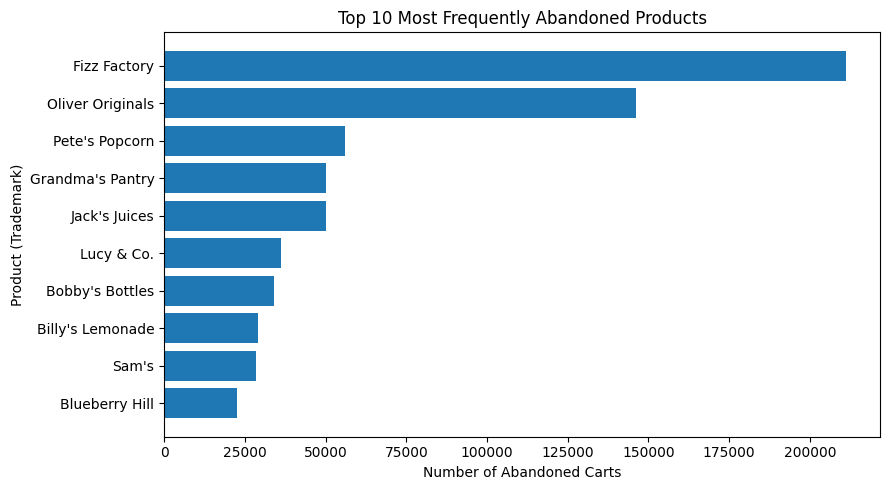

In [30]:
# ============================================
# Top Abandoned Products (combine material_ids by trademark)
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) filter to abandoned only
abandoned_df = df[df["abandoned"] == True].copy()

# 1) count ALL abandoned item_ids (don't cap yet; we'll group by trademark first)
item_counts = (
    abandoned_df["item_id"]
    .astype(str)                      # align dtype early
    .value_counts()
    .to_frame("count")
    .reset_index()
    .rename(columns={"index": "item_id"})
)

# 2) detect the product name column present in `materials`
name_col = None
for candidate in ["trademark", "trade_mark_desc", "product_name", "material_desc", "name"]:
    if candidate in materials.columns:
        name_col = candidate
        break

if name_col is None:
    raise KeyError(
        "Couldn't find a product name/description column in `materials`. "
        "Tried: ['trademark','trade_mark_desc','product_name','material_desc','name'].\n"
        f"materials columns are: {list(materials.columns)}"
    )

# 3) align dtype for merge key
materials = materials.copy()
if "material_id" not in materials.columns:
    raise KeyError("`materials` is missing 'material_id' column.")
materials["material_id"] = materials["material_id"].astype(str)

# 4) merge item counts -> materials to attach product/trademark
merged = item_counts.merge(
    materials[["material_id", name_col]],
    left_on="item_id",
    right_on="material_id",
    how="left"
)

# 5) group by trademark so multiple material_ids for the same product are combined
grouped = (
    merged.groupby(name_col, dropna=False)["count"]
    .sum()
    .reset_index()
    .rename(columns={name_col: "product_name"})
    .sort_values("count", ascending=False)
)

# 6) take top 10 products after combining
top10_products = grouped.head(10).reset_index(drop=True)

# 7) print a clean table
print("\nTop 10 Most Frequently Abandoned Products (combined by product/trademark):")
print(top10_products.to_string(index=False))

# 8) plot a sorted horizontal bar chart (highest on top)
plt.figure(figsize=(9, 5))
labels = top10_products["product_name"].fillna("(unknown)")
counts = top10_products["count"]

# reverse so the largest appears on top
plt.barh(labels[::-1], counts[::-1])
plt.xlabel("Number of Abandoned Carts")
plt.ylabel("Product (Trademark)")
plt.title("Top 10 Most Frequently Abandoned Products")
plt.tight_layout()
plt.show()


The top 3 most frequently abandoned products are: Fizz Factory, Oliver Originals and Petes Popcorn. 